In [1]:
train_dir = r"E:\Project_Deepfake\Frames\train"
val_dir   = r"E:\Project_Deepfake\Frames\val"

In [2]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout ,Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
#from tensorflow.keras.applications import Xception

## Preprocessing 


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True   # keep it minimal
)

In [4]:
val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [5]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

Found 7449 images belonging to 2 classes.


In [7]:
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',shuffle=False
)

Found 1863 images belonging to 2 classes.


In [8]:
print("Class indices:", train_data.class_indices)

Class indices: {'fake': 0, 'real': 1}


In [9]:
images, labels = next(train_data)

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)

Image batch shape: (32, 128, 128, 3)
Labels shape: (32,)


## Our CNN Model

In [10]:
model= Sequential()
model.add(Conv2D(32,(3,3), padding='valid',activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,(3,3), padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,(3,3), padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 128)      0

In [12]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

In [14]:
history = model.fit(
    train_data,
    epochs=10,
    callbacks=[early_stop],
    validation_data=val_data
)

Epoch 1/10
233/233 [==============================] - 17s 53ms/step - loss: 0.6631 - accuracy: 0.5896 - val_loss: 0.6507 - val_accuracy: 0.6146
Epoch 2/10
233/233 [==============================] - 11s 46ms/step - loss: 0.5608 - accuracy: 0.7127 - val_loss: 0.5250 - val_accuracy: 0.7236
Epoch 3/10
233/233 [==============================] - 11s 46ms/step - loss: 0.4894 - accuracy: 0.7578 - val_loss: 0.4883 - val_accuracy: 0.7611
Epoch 4/10
233/233 [==============================] - 11s 47ms/step - loss: 0.4612 - accuracy: 0.7759 - val_loss: 0.4757 - val_accuracy: 0.7821
Epoch 5/10
233/233 [==============================] - 11s 46ms/step - loss: 0.4173 - accuracy: 0.8078 - val_loss: 0.4244 - val_accuracy: 0.7992
Epoch 6/10
233/233 [==============================] - 11s 46ms/step - loss: 0.3789 - accuracy: 0.8271 - val_loss: 0.3987 - val_accuracy: 0.8191
Epoch 7/10
233/233 [==============================] - 11s 46ms/step - loss: 0.3462 - accuracy: 0.8435 - val_loss: 0.3926 - val_accuracy:

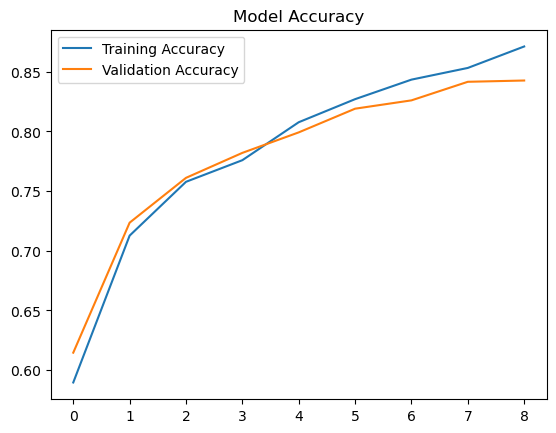

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()


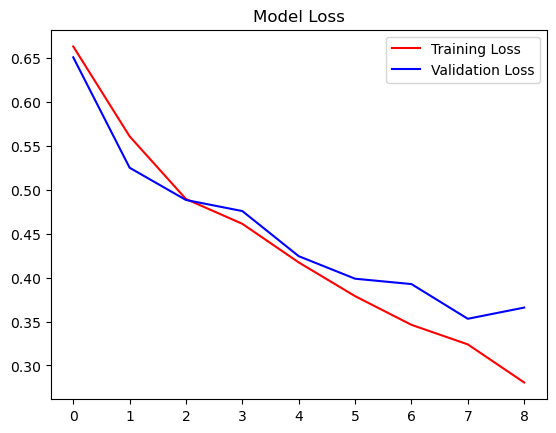

In [16]:
plt.plot(history.history['loss'], label='Training Loss',color='red')
plt.plot(history.history['val_loss'], label='Validation Loss',color='blue')
plt.title('Model Loss')
plt.legend()
plt.show()

## Confusion Matrix

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
val_data.reset()
# Predict probabilities
y_pred_prob = model.predict(val_data)

# Convert to 0/1
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

# True labels
y_true = val_data.classes

59/59 [==============================] - 1s 22ms/step


In [19]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[753 156]
 [139 815]]


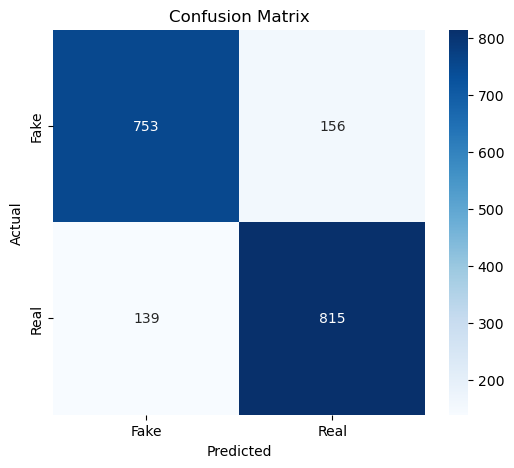

In [20]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## Model Saving

In [ ]:
model.save("E:/Project_Deepfake/Deepfake_Video/models/deepfake_model2.keras")

In [ ]:
from tensorflow.keras.models import load_model
model = load_model(r"E:\Project_Deepfake\Deepfake_Video\models\deepfake_model2.keras")

## Testing

In [3]:
import cv2

def predict_video(video_path):
    cap = cv2.VideoCapture(video_path)

    frame_count = 0
    predictions = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # sample every 5th frame
        if frame_count % 10 == 0:
            frame = cv2.resize(frame, (128, 128))
            frame = frame / 255.0
            frame = np.expand_dims(frame, axis=0)

            pred = model.predict(frame, verbose=0)[0][0]
            predictions.append(pred)

            # limit frames (like training)
            if len(predictions) >= 20:
                break

        frame_count += 1

    cap.release()

    # Average prediction
    avg_pred = np.mean(predictions)

    print(f"Average prediction: {avg_pred:.4f}")

    if avg_pred > 0.5:
        print("Result: REAL")
    else:
        print("Result: FAKE")

In [ ]:
predict_video(r"E:\Project_Deepfake\check.mp4")


Average prediction: 0.0303
Result: FAKE
